In [2]:

# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time

from collections import defaultdict
from itertools import product

In [3]:

# ============================================================
# CUSTOM DRONE RESCUE ENVIRONMENT
# ============================================================

class DroneRescueEnvironment:

    def __init__(self):

        # Grid size 5*5 for Group ID 121 as last digit odd
        self.grid_size = 5

        # Battery because last digit is odd
        self.max_battery = 15

        # Wind probability because last digit is between 0-4
        self.wind_probability = 0.20

        # Maximum episode steps
        self.max_steps = 50

        # Start position
        self.start_position = (0, 0)

        # Rescue targets
        self.rescue_targets = [(1, 3), (4, 1)]

        # Charging station
        self.charging_stations = [(2, 4)]

        # Danger zones
        self.danger_zones = [(1, 1), (3, 2), (4, 4)]

        # Wind zones
        self.wind_zones = [(0, 2), (2, 3)]

        # Blocked cells
        self.blocked_cells = [(1, 4), (3, 0)]

        # Action definitions
        self.actions = {
            0: (-1, 0),   # UP
            1: (1, 0),    # DOWN
            2: (0, -1),   # LEFT
            3: (0, 1),    # RIGHT
            4: (0, 0)     # HOVER
        }

        self.action_names = {
            0: 'UP',
            1: 'DOWN',
            2: 'LEFT',
            3: 'RIGHT',
            4: 'HOVER'
        }

        self.reset()

    # ========================================================
    # RESET ENVIRONMENT
    # ========================================================

    def reset(self):

        self.position = self.start_position
        self.battery = self.max_battery
        self.steps = 0

        self.rescued = tuple([False] * len(self.rescue_targets)) #To keep track of already rescued targets

        return self.get_state()

    # ========================================================
    # GET CURRENT STATE
    # ========================================================

    def get_state(self):

        return (
            self.position[0],
            self.position[1],
            self.battery,
            self.rescued
        )

    # ========================================================
    # CHECK VALID CELL
    # ========================================================

    def is_valid_cell(self, row, col):

        if row < 0 or row >= self.grid_size:
            return False

        if col < 0 or col >= self.grid_size:
            return False

        if (row, col) in self.blocked_cells:  #No movement in blocked cells
            return False

        return True

    # ========================================================
    # GET VALID ACTIONS
    # ========================================================

    def get_valid_actions(self, state):

        valid_actions = []

        row, col, battery, rescued = state

        for action in self.actions:

            move_row, move_col = self.actions[action]

            new_row = row + move_row
            new_col = col + move_col

            if action == 4:
                valid_actions.append(action)

            else:
                if self.is_valid_cell(new_row, new_col):
                    valid_actions.append(action)

        return valid_actions

    # ========================================================
    # STEP FUNCTION
    # ========================================================

    def step(self, action):

        reward = -1

        self.steps += 1

        current_row, current_col = self.position

        # Wind disturbance handling
        if self.position in self.wind_zones and action != 4:

            if random.random() < self.wind_probability:
                action = random.choice([0, 1, 2, 3])

        move_row, move_col = self.actions[action]

        next_row = current_row + move_row
        next_col = current_col + move_col

        # Invalid move handling
        if not self.is_valid_cell(next_row, next_col):
            next_row, next_col = current_row, current_col

        self.position = (next_row, next_col)

        # Battery decreases
        self.battery -= 1

        # Charging station logic
        if self.position in self.charging_stations:

            if action == 4:
                self.battery = min(self.max_battery,
                                   self.battery + 2)

            else:
                self.battery = self.max_battery
                reward += 5

        # Danger penalty
        if self.position in self.danger_zones:
            reward -= 10

        # Rescue logic
        rescued_list = list(self.rescued)

        for index, target in enumerate(self.rescue_targets):

            if self.position == target and not rescued_list[index]:

                reward += 20
                rescued_list[index] = True

        self.rescued = tuple(rescued_list)

        done = False

        # Battery exhausted
        if self.battery <= 0:
            reward -= 20
            done = True

        # All rescue targets completed
        if all(self.rescued):
            done = True

        # Step limit reached
        if self.steps >= self.max_steps:
            done = True

        return self.get_state(), reward, done

    # ========================================================
    # RENDER ENVIRONMENT
    # ========================================================

    def render(self):

        grid = [['F' for _ in range(self.grid_size)]
                for _ in range(self.grid_size)]

        grid[0][0] = 'S'

        for target in self.rescue_targets:
            grid[target[0]][target[1]] = 'R'

        for station in self.charging_stations:
            grid[station[0]][station[1]] = 'C'

        for danger in self.danger_zones:
            grid[danger[0]][danger[1]] = 'D'

        for wind in self.wind_zones:
            grid[wind[0]][wind[1]] = 'W'

        for blocked in self.blocked_cells:
            grid[blocked[0]][blocked[1]] = 'X'

        drone_row, drone_col = self.position

        grid[drone_row][drone_col] = 'A'  #Drone Position

        print("\nCURRENT ENVIRONMENT")
        print("-" * 40)

        for row in grid:
            print(row)

        print(f"Battery : {self.battery}")
        print(f"Steps   : {self.steps}")
        print(f"Rescued : {self.rescued}")


In [4]:

# ============================================================
# CREATE ENVIRONMENT
# ============================================================

env = DroneRescueEnvironment()

print("INITIAL ENVIRONMENT")

env.render()


INITIAL ENVIRONMENT

CURRENT ENVIRONMENT
----------------------------------------
['A', 'F', 'W', 'F', 'F']
['F', 'D', 'F', 'R', 'X']
['F', 'F', 'F', 'W', 'C']
['X', 'F', 'D', 'F', 'F']
['F', 'R', 'F', 'F', 'D']
Battery : 15
Steps   : 0
Rescued : (False, False)


In [5]:

# ============================================================
# ENUMERATE STATES
# ============================================================

def enumerate_states(environment):

    states = []

    rescue_combinations = list(
        product([False, True],
                repeat=len(environment.rescue_targets))
    )

    for row in range(environment.grid_size):

        for col in range(environment.grid_size):

            if (row, col) in environment.blocked_cells:
                continue

            for battery in range(1,
                                 environment.max_battery + 1):

                for rescue_status in rescue_combinations:

                    state = (
                        row,
                        col,
                        battery,
                        rescue_status
                    )

                    states.append(state)

    return states

all_states = enumerate_states(env)

print(f"Total Number of States : {len(all_states)}")


Total Number of States : 1380


In [6]:

# ============================================================
# TRANSITION FUNCTION
# ============================================================

def get_transition(environment, state, action):

    row, col, battery, rescued = state

    if battery <= 0:
        return state, -20, True

    move_row, move_col = environment.actions[action]

    next_row = row + move_row
    next_col = col + move_col

    if not environment.is_valid_cell(next_row, next_col):
        next_row, next_col = row, col

    next_battery = battery - 1

    reward = -1

    if (next_row, next_col) in environment.charging_stations:

        if action == 4:
            next_battery = min(environment.max_battery,
                               next_battery + 2)

        else:
            next_battery = environment.max_battery
            reward += 5

    if (next_row, next_col) in environment.danger_zones:
        reward -= 10

    rescued_list = list(rescued)

    for index, target in enumerate(environment.rescue_targets):

        if (next_row, next_col) == target and not rescued_list[index]:

            reward += 20
            rescued_list[index] = True

    rescued_tuple = tuple(rescued_list)

    done = False

    if next_battery <= 0:
        reward -= 20
        done = True

    if all(rescued_tuple):
        done = True

    next_state = (
        next_row,
        next_col,
        next_battery,
        rescued_tuple
    )

    return next_state, reward, done


In [7]:

# ============================================================
# VALUE ITERATION
# ============================================================

def value_iteration(environment,
                    gamma=0.90,
                    theta=1e-3):

    states = enumerate_states(environment)

    V = defaultdict(float)

    iteration = 0

    start_time = time.time()

    while True:

        delta = 0

        iteration += 1

        for state in states:

            old_value = V[state]

            valid_actions = environment.get_valid_actions(state)

            action_values = []

            for action in valid_actions:

                next_state, reward, done = get_transition(
                    environment,
                    state,
                    action
                )

                value = reward + gamma * V[next_state]

                action_values.append(value)

            if len(action_values) > 0:
                V[state] = max(action_values)

            delta = max(delta,
                        abs(old_value - V[state]))

        print(f"Iteration {iteration} | Delta = {delta:.6f}")

        if delta < theta:
            break

    policy = {}

    for state in states:

        valid_actions = environment.get_valid_actions(state)

        best_action = None
        best_value = float('-inf')

        for action in valid_actions:

            next_state, reward, done = get_transition(
                environment,
                state,
                action
            )

            value = reward + gamma * V[next_state]

            if value > best_value:
                best_value = value
                best_action = action

        policy[state] = best_action

    end_time = time.time()

    print("\nVALUE ITERATION COMPLETED")
    print("=" * 50)
    print(f"Total Iterations : {iteration}")
    print(f"Final Delta      : {delta:.6f}")
    print(f"Runtime          : {end_time - start_time:.4f} seconds")

    return V, policy


In [8]:

# ============================================================
# RUN VALUE ITERATION
# ============================================================

V_optimal, optimal_policy = value_iteration(env)


Iteration 1 | Delta = 21.000000
Iteration 2 | Delta = 18.900000
Iteration 3 | Delta = 17.010000
Iteration 4 | Delta = 15.309000
Iteration 5 | Delta = 13.778100
Iteration 6 | Delta = 10.760040
Iteration 7 | Delta = 8.787803
Iteration 8 | Delta = 4.840844
Iteration 9 | Delta = 1.129718
Iteration 10 | Delta = 0.734317
Iteration 11 | Delta = 0.594797
Iteration 12 | Delta = 0.481785
Iteration 13 | Delta = 0.390246
Iteration 14 | Delta = 0.316099
Iteration 15 | Delta = 0.256040
Iteration 16 | Delta = 0.207393
Iteration 17 | Delta = 0.167988
Iteration 18 | Delta = 0.136070
Iteration 19 | Delta = 0.110217
Iteration 20 | Delta = 0.089276
Iteration 21 | Delta = 0.072313
Iteration 22 | Delta = 0.058574
Iteration 23 | Delta = 0.047445
Iteration 24 | Delta = 0.038430
Iteration 25 | Delta = 0.031129
Iteration 26 | Delta = 0.025214
Iteration 27 | Delta = 0.020423
Iteration 28 | Delta = 0.016543
Iteration 29 | Delta = 0.013400
Iteration 30 | Delta = 0.010854
Iteration 31 | Delta = 0.008792
Iteration 3

In [9]:

# ============================================================
# VISUALIZE POLICY
# ============================================================

def visualize_policy(environment,
                     policy,
                     battery_level=10,
                     rescue_status=(False, False)):

    arrows = {
        0: '↑',
        1: '↓',
        2: '←',
        3: '→',
        4: 'H'
    }

    grid = [['' for _ in range(environment.grid_size)]
            for _ in range(environment.grid_size)]

    for row in range(environment.grid_size):

        for col in range(environment.grid_size):

            if (row, col) in environment.blocked_cells:
                grid[row][col] = 'X'
                continue

            state = (
                row,
                col,
                battery_level,
                rescue_status
            )

            action = policy.get(state, 4)

            grid[row][col] = arrows[action]

    print("\nOPTIMAL POLICY GRID")
    print("=" * 40)

    for row in grid:
        print(row)

visualize_policy(env, optimal_policy)



OPTIMAL POLICY GRID
['→', '→', '↓', '↓', '←']
['↓', '→', '→', 'H', 'X']
['→', '↓', '→', '↑', '←']
['X', '↓', '↓', '↑', '↑']
['→', 'H', '←', '←', '←']


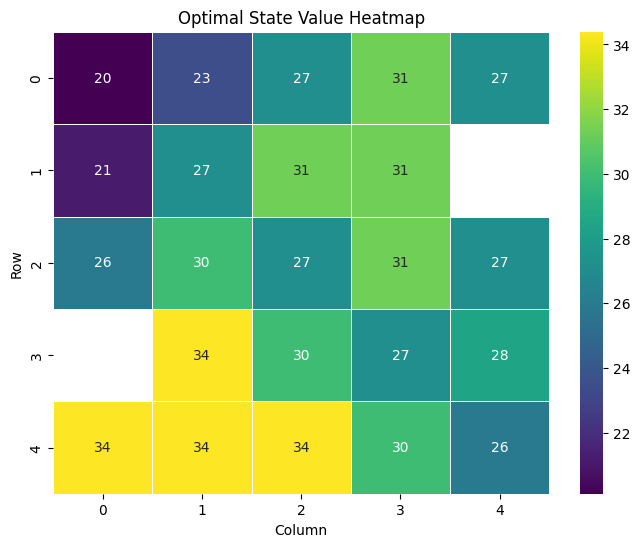

In [10]:

# ============================================================
# PLOT HEATMAP
# ============================================================

def plot_state_value_heatmap(environment,
                             V,
                             battery_level=10,
                             rescue_status=(False, False)):

    value_grid = np.zeros((
        environment.grid_size,
        environment.grid_size
    ))

    for row in range(environment.grid_size):

        for col in range(environment.grid_size):

            if (row, col) in environment.blocked_cells:
                value_grid[row][col] = np.nan

            else:

                state = (
                    row,
                    col,
                    battery_level,
                    rescue_status
                )

                value_grid[row][col] = V[state]

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        value_grid,
        annot=True,
        cmap='viridis',
        linewidths=0.5
    )

    plt.title('Optimal State Value Heatmap')

    plt.xlabel('Column')
    plt.ylabel('Row')

    plt.show()

plot_state_value_heatmap(env, V_optimal)


In [12]:

# ============================================================
# POLICY EXECUTION SIMULATION
# ============================================================

def simulate_policy(environment,
                    policy,
                    max_steps=50):

    state = environment.reset()

    total_reward = 0

    print("\nSTARTING POLICY EXECUTION")
    print("=" * 50)

    for step in range(max_steps):

        environment.render()

        action = policy[state]

        print(f"Selected Action : {environment.action_names[action]}")

        next_state, reward, done = environment.step(action)

        total_reward += reward

        print(f"Reward Received : {reward}")
        print(f"Total Reward    : {total_reward}")

        state = next_state

        if done:
            print("\nEPISODE TERMINATED")
            break

    print("=" * 50)
    print(f"Final Reward : {total_reward}")

simulate_policy(env, optimal_policy)



STARTING POLICY EXECUTION

CURRENT ENVIRONMENT
----------------------------------------
['A', 'F', 'W', 'F', 'F']
['F', 'D', 'F', 'R', 'X']
['F', 'F', 'F', 'W', 'C']
['X', 'F', 'D', 'F', 'F']
['F', 'R', 'F', 'F', 'D']
Battery : 15
Steps   : 0
Rescued : (False, False)
Selected Action : RIGHT
Reward Received : -1
Total Reward    : -1

CURRENT ENVIRONMENT
----------------------------------------
['S', 'A', 'W', 'F', 'F']
['F', 'D', 'F', 'R', 'X']
['F', 'F', 'F', 'W', 'C']
['X', 'F', 'D', 'F', 'F']
['F', 'R', 'F', 'F', 'D']
Battery : 14
Steps   : 1
Rescued : (False, False)
Selected Action : RIGHT
Reward Received : -1
Total Reward    : -2

CURRENT ENVIRONMENT
----------------------------------------
['S', 'F', 'A', 'F', 'F']
['F', 'D', 'F', 'R', 'X']
['F', 'F', 'F', 'W', 'C']
['X', 'F', 'D', 'F', 'F']
['F', 'R', 'F', 'F', 'D']
Battery : 13
Steps   : 2
Rescued : (False, False)
Selected Action : DOWN
Reward Received : -1
Total Reward    : -3

CURRENT ENVIRONMENT
-----------------------------